# Notebook 9: Pivot Tables in Pandas

Pivot tables gives us a powerful way to group information from complex tables. You can read [this article on pivot tables](https://builtin.com/data-science/pandas-pivot-tables) before you work through this notebook. We will use a database on automobiles that give 26 different properties of 205 different cars, from 1985. This database in publicly available in python through the sklearns.datasets package.

In [1]:
#This just reads in the dataset, do not modify.
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_openml

X, y = fetch_openml("autos", version=1, as_frame=True, return_X_y=True, parser='auto')
data = X

In [ ]:
data

,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,13495.0
1,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,...,130,mpfi,3.47,2.68,9.0,111.0,5000.0,21,27,16500.0
2,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,...,152,mpfi,2.68,3.47,9.0,154.0,5000.0,19,26,16500.0
3,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,...,109,mpfi,3.19,3.40,10.0,102.0,5500.0,24,30,13950.0
4,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,...,136,mpfi,3.19,3.40,8.0,115.0,5500.0,18,22,17450.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,9.5,114.0,5400.0,23,28,16845.0
201,95.0,volvo,gas,turbo,four,sedan,rwd,front,109.1,188.8,...,141,mpfi,3.78,3.15,8.7,160.0,5300.0,19,25,19045.0
202,95.0,volvo,gas,std,four,sedan,rwd,front,109.1,188.8,...,173,mpfi,3.58,2.87,8.8,134.0,5500.0,18,23,21485.0
203,95.0,volvo,diesel,turbo,four,sedan,rwd,front,109.1,188.8,...,145,idi,3.01,3.40,23.0,106.0,4800.0,26,27,22470.0


This a lot of information, 205 rows by 25 columns. We can use the following to display the whole data table.

In [2]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
data

,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,height,curb-weight,engine-type,num-of-cylinders,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111.0,5000.0,21,27,13495.0
1,NaN,alfa-romero,gas,std,two,convertible,rwd,front,88.6,168.8,64.1,48.8,2548,dohc,four,130,mpfi,3.47,2.68,9.00,111.0,5000.0,21,27,16500.0
2,NaN,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,171.2,65.5,52.4,2823,ohcv,six,152,mpfi,2.68,3.47,9.00,154.0,5000.0,19,26,16500.0
3,164.0,audi,gas,std,four,sedan,fwd,front,99.8,176.6,66.2,54.3,2337,ohc,four,109,mpfi,3.19,3.40,10.00,102.0,5500.0,24,30,13950.0
4,164.0,audi,gas,std,four,sedan,4wd,front,99.4,176.6,66.4,54.3,2824,ohc,five,136,mpfi,3.19,3.40,8.00,115.0,5500.0,18,22,17450.0
5,NaN,audi,gas,std,two,sedan,fwd,front,99.8,177.3,66.3,53.1,2507,ohc,five,136,mpfi,3.19,3.40,8.50,110.0,5500.0,19,25,15250.0
6,158.0,audi,gas,std,four,sedan,fwd,front,105.8,192.7,71.4,55.7,2844,ohc,five,136,mpfi,3.19,3.40,8.50,110.0,5500.0,19,25,17710.0
7,NaN,audi,gas,std,four,wagon,fwd,front,105.8,192.7,71.4,55.7,2954,ohc,five,136,mpfi,3.19,3.40,8.50,110.0,5500.0,19,25,18920.0
8,158.0,audi,gas,turbo,four,sedan,fwd,front,105.8,192.7,71.4,55.9,3086,ohc,five,131,mpfi,3.13,3.40,8.30,140.0,5500.0,17,20,23875.0
9,NaN,audi,gas,turbo,two,hatchback,4wd,front,99.5,178.2,67.9,52.0,3053,ohc,five,131,mpfi,3.13,3.40,7.00,160.0,5500.0,16,22,NaN


## A basic pivot table
Suppose we would like to know the mean price of a car as a function of the number of doors (2 or 4), and the fuel type (gas or diesel). (Note that this table is from the 80s when diesel cars were briefly popular). That information is available from the large table above, but it would take work to get it. With pivot tables, we can contruct this in a single line.

In [3]:
pivot = np.round(pd.pivot_table(data, values='price',
                                index='num-of-doors',
                                columns='fuel-type',
                                aggfunc='mean', observed=False),2)
pivot

fuel-type,diesel,gas
num-of-doors,,
four,16432.38,13092.81
two,14350.00,12762.76


## Exercise 1

Produce and display a pivot table giving the mean "price" as a function of engine "aspiration" (standard or turbo) for the rows and "drive-wheels" (four-wheel-drive, front-wheel-drive, or rear-wheel-drive) for the columns.

In [4]:
#YOUR CODE HERE!
pivot2 = np.round(pd.pivot_table(data, values='price',
                                 index='aspiration',
                                 columns='drive-wheels',
                                 aggfunc='mean', observed=False),2)
pivot2


drive-wheels,4wd,fwd,rwd
aspiration,,,
std,9829.17,8724.03,19660.25
turbo,11476.50,12564.56,20065.94


As a check, the most expensive combination should be turbo rear-wheel-drive vehicles, with a mean price of $20,065.94.

## Multi-level pivot tables
You can provide multiple entries to both the index (rows) and the columns to create more complex pivot tables.

In [ ]:
pivot = np.round(pd.pivot_table(data, values='price',
                                index=['num-of-doors', 'body-style'],
                                columns=['fuel-type', 'fuel-system'],
                                aggfunc='mean', observed=False),2)
pivot

fuel-type                   diesel      gas                             \
fuel-system                    idi     1bbl     2bbl     4bbl      mfi   
num-of-doors body-style                                                  
four         hatchback     7788.00      NaN  7813.71      NaN      NaN   
             sedan        16328.92  8811.67  7711.19      NaN      NaN   
             wagon        19727.67  7295.00  8028.89      NaN      NaN   
two          convertible       NaN      NaN      NaN      NaN      NaN   
             hardtop      28176.00      NaN  8249.00      NaN      NaN   
             hatchback         NaN  7054.43  6701.67  12145.0  12964.0   
             sedan         7437.00      NaN  7570.00      NaN      NaN   

fuel-type                                              
fuel-system                   mpfi      spdi     spfi  
num-of-doors body-style                                
four         hatchback    10618.00       NaN      NaN  
             sedan        18425.68   9279.00      NaN  
             wagon        14213.42       NaN      NaN  
two          convertible  21890.50       NaN      NaN  
             hardtop      23540.50       NaN      NaN  
             hatchback    14581.50  11479.43  11048.0  
             sedan        21034.00       NaN      NaN

Note: The NaN (Not a Number) entries are expected and mean that that particular combination does not exist in this database.

## Exercise 2

Produce and display a pivot table giving the mean "price" as a function of "num-of-doors" and "body-style" for the rows and "aspiration" (standard or turbo) and "drive-wheels" (four-wheel-drive, front-wheel-drive, or rear-wheel-drive) for the columns.

In [5]:
#YOUR CODE HERE!
pivot3 = np.round(pd.pivot_table(data, values='price',
                                 index=['num-of-doors', 'body-style'],
                                 columns = ['aspiration', 'drive-wheels'],
                                 aggfunc= 'mean', observed=False),2)
pivot3


aspiration                     std                        turbo            \
drive-wheels                   4wd       fwd       rwd      4wd       fwd   
num-of-doors body-style                                                     
four         hatchback         NaN   8372.00       NaN      NaN       NaN   
             sedan        13341.50   9399.82  22182.15  11259.0  14302.00   
             wagon         8229.67   9997.33  14963.00  11694.0       NaN   
two          convertible       NaN  11595.00  23949.60      NaN       NaN   
             hardtop           NaN   8249.00  23540.50      NaN       NaN   
             hatchback     7603.00   7368.00  13940.93      NaN  11851.44   
             sedan             NaN   8486.38  22011.83      NaN       NaN   

aspiration                          
drive-wheels                   rwd  
num-of-doors body-style             
four         hatchback         NaN  
             sedan        20591.20  
             wagon        19533.25  
two          convertible       NaN  
             hardtop      28176.00  
             hatchback    16322.00  
             sedan             NaN

As a check, the most expensive combination should be turbo, rear-wheel-drive, two-door, hardtop vehicles, with a mean price of $28,176.00.

## Data visualization with pivot tables

We can call .plot immediately after constucting the pivot table in order to display different types of plots. Below we display the mean car price by make of car and the number of doors in a horizontal bar plot (.plot.barh).

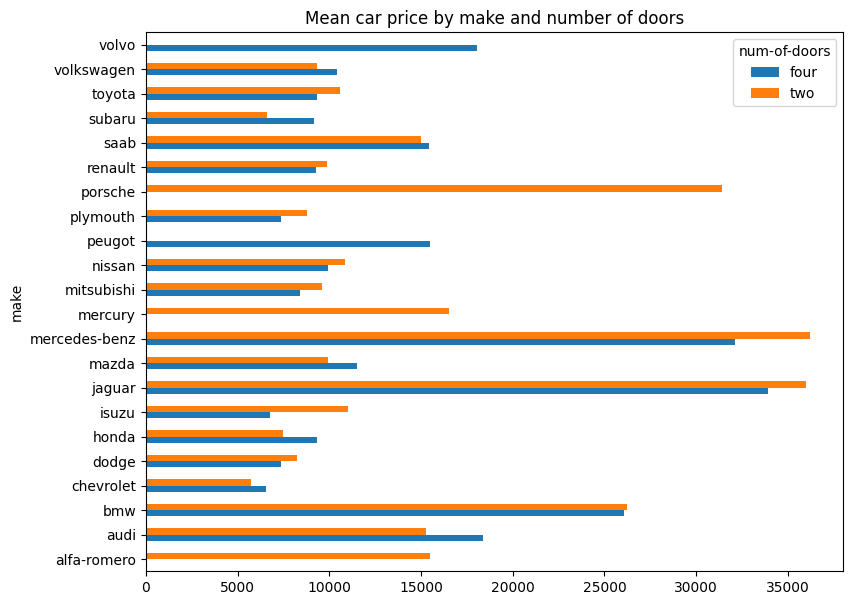

In [ ]:
pivot = pd.pivot_table(data, values='price',
            index=['make'],
            columns=['num-of-doors'],
            aggfunc='mean', observed=False).plot.barh(figsize=(9,7),
            title='Mean car price by make and number of doors')

## Exercise 3

Create a pivot table of mean "price" as a function of "drive-wheels" (four-wheel-drive, front-wheel-drive, or rear-wheel-drive) for the rows and "num-of-doors" for the columns, and instead of printing it, display it as a vertical bar plot (.bar instead of .barh).

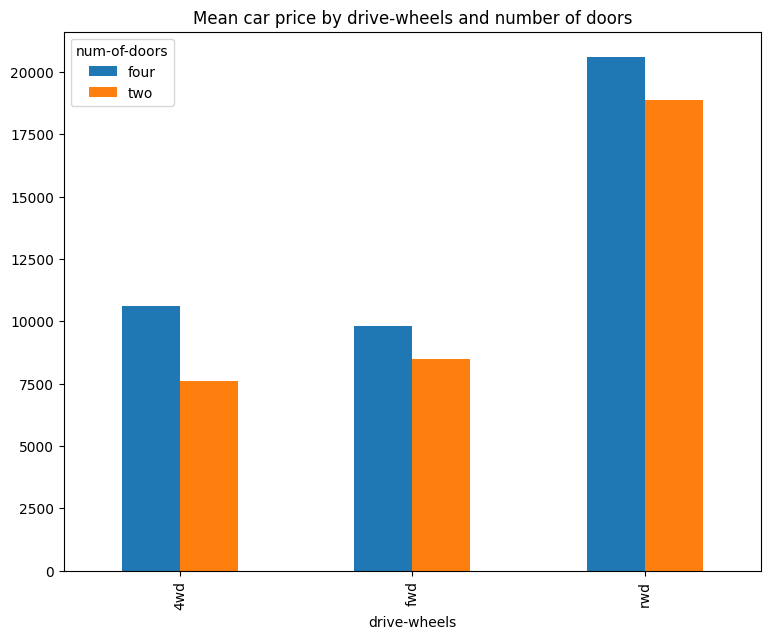

In [6]:
#YOUR CODE HERE!
pivot4 = pd.pivot_table(data, values = 'price',
                        index = ['drive-wheels'],
                        columns = ['num-of-doors'],
                        aggfunc = 'mean', observed = False).plot.bar(figsize = (9,7),
                        title='Mean car price by drive-wheels and number of doors')


## Adding multiple functions to a pivot table

We do not alway have to compute the mean. Any function that generates one number from a list of numbers will work; for example, median, min, max, sum, etc. Below we use a pivot table to display both the mean and the median of the price as function of body style and number of doors.

In [ ]:
pivot = np.round(pd.pivot_table(data, values='price',
                                index=['body-style'],
                                columns=['num-of-doors'],
                                aggfunc=['mean', 'median'],
                                fill_value=0, observed=False),2)
pivot

mean             median         
num-of-doors      four       two     four      two
body-style                                        
convertible       0.00  21890.50      0.0  17084.5
hardtop           0.00  22208.50      0.0  19687.5
hatchback      8372.00  10230.79   8073.0   8970.0
sedan         14614.13  14283.00  12555.0   8678.0
wagon         12371.96      0.00  11694.0      0.0

Note that in all of these cases the mean is higher than the equivalent median. This is because high-prices of expensive items increase the mean much more than they increase the median. For this reason, the median is actually a better estimate of typical price than the mean.

## Exercise 4

Produce and print a pivot table giving both the mean and median "price" as a function of engine "aspiration" (standard or turbo) for the rows and "drive-wheels" (four-wheel-drive, front-wheel-drive, or rear-wheel-drive) for the columns.

In [7]:
#YOUR CODE HERE!
pivot5 = np.round(pd.pivot_table(data, values = 'price',
                                 index = ['aspiration'],
                                 columns = ['drive-wheels'],
                                 aggfunc = ['mean', 'median'],
                                 fill_value = 0, observed = False),2)
pivot5

mean                       median                  
drive-wheels       4wd       fwd       rwd      4wd      fwd      rwd
aspiration                                                           
std            9829.17   8724.03  19660.25   8395.5   7896.5  16515.0
turbo         11476.50  12564.56  20065.94  11476.5  11663.5  18685.0

As a check, the highest median price should be for turbo rear-wheel-drive vehicles, with a median price of $18685.00. Note that in this case too the mean price is always greater than or equal to the median price.

## Exercise 5

Suppose we want to know what type of car gets the best gas mileage. Produce and print a pivot table giving the mean "highway-mpg" as a function of both "num-of-doors" and "body-style" for the rows, and "drive-wheels" (four-wheel-drive, front-wheel-drive, or rear-wheel-drive) for the columns.

In [8]:
#YOUR CODE HERE!
pivot6= np.round(pd.pivot_table(data, values = 'highway-mpg',
                                index = ['num-of-doors', 'body-style'],
                                columns = ['drive-wheels'],
                                aggfunc = 'mean', observed = False),2)
pivot6


drive-wheels                4wd    fwd    rwd
num-of-doors body-style                      
four         hatchback      NaN  36.20    NaN
             sedan        25.33  33.63  25.53
             wagon        29.00  31.42  25.00
two          convertible    NaN  29.00  25.40
             hardtop        NaN  37.00  25.86
             hatchback    26.50  34.44  26.00
             sedan          NaN  37.78  26.50

What combination of number of doors, body type, and drive wheels gives the best (highest) mean mileage, and what is the mean miles per gallon for this combination? Put your answer in the markdown cell below.

**37.78**
